# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Helen Ayalew

**Date:** 09/02/2026

In [5]:
# Your Phase 1 solution to the problem goes here.

# All of my imports needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Question 1 Part 1:
# Saving the csv data to a pandas dataframe
df = pd.read_csv('data/airbnb_hw.csv')

# Copy of cleaned Price column from originial data set
df.to_csv('data/cleaned_data_airbnb_hw.csv', index=False)

# Displaying the first 5 rows of the dataframe and the Price column
df.head()
df['Price'].head()

# Checking for commas in the Price column
df[df['Price'].str.contains(',')]

# Removing the commas from the Price column
df['Price'] = df['Price'].str.replace(',', '')

# Checking the table after the commas have been removed
df[df['Price'].str.contains('')]

# Converting the Prices column from an object to an integer
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print(df['Price'].dtype)

# Displaying the numbers larger than 999 in the Price column
df['Price'][df['Price'] > 999].head()

int64


101     1990
263     1000
764     1200
1272    1000
1275    5000
Name: Price, dtype: int64

Question: How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

Answer: I ended up with zero missing values. The prices of the formatting when the prices are above 999 become the number without a comma (such as before: 1,990 after: 1990).

In [ ]:
# Question 1 Part 2:

# Saving the csv data to a pandas dataframe
df = pd.read_csv('data/mn_police_use_of_force.csv')

# Saving the csv data to a pandas dataframe
df.to_csv('data/cleaned_mn_police_use_of_force.csv', index=False)

# Displaying the first 5 rows of the dataframe, the subject_injury column, and the force_type column
df.head()
df['subject_injury'].head()
df['force_type'].head()

# Missing values in the subject_injury column
missing_values = df[df['subject_injury'].isnull()].count()
print(missing_values)

# Cross tabulation of the subject_injury and force_type columns
result = pd.crosstab(df['subject_injury'], df['force_type'])
print(result)

# Filling in missing subject_injury with force_type data
df['subject_injury'] = df['subject_injury'].fillna(df['force_type'].map({
    'Bodily Force': 'Yes',
    'Chemical Irritant': 'No',
    'Taser': 'No',
    'Improvised Weapon': 'No',
    'Gun Point Display': 'Yes',
    'Police K9 Bite': 'Yes'
}))

# Displaying only the subject_injury and force_type columns of the dataframe
df[['subject_injury', 'force_type']]

response_datetime    9848
problem              9848
is_911_call          9848
primary_offense      9848
subject_injury          0
force_type           9848
force_type_action    9848
race                 8900
sex                  9361
age                  8782
type_resistance      6862
precinct             9848
neighborhood         9844
dtype: int64
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury     

,subject_injury,force_type
0,Yes,Bodily Force
1,No,Chemical Irritant
2,No,Chemical Irritant
3,No,Chemical Irritant
4,No,Chemical Irritant
...,...,...
12920,Yes,Bodily Force
12921,Yes,Bodily Force
12922,Yes,Bodily Force
12923,Yes,Bodily Force


Questions: What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

Answers: The proportion of the values that are missing are about 75% (3/4). Yes, this is a concern because that is more than half of the data missing. The patterns regarding when the data are missing are the groupings of the different kinds of crimes and the same day.

0    2026.0
1    2026.0
2    2026.0
3    2026.0
4    2026.0
Name: Year, dtype: float64
7112    0.0
7113    0.0
7114    0.0
7115    0.0
7116    0.0
Name: Year, dtype: float64
              Date    Year        Type           Country  \
0      26th August  2026.0  Unprovoked               USA   
1     23rd August   2026.0  Unprovoked               USA   
2      19th August  2026.0    Provoked    Reunion Island   
3      11th August  2026.0    Provoked           Ireland   
4       8th August  2026.0  Unprovoked               USA   
...            ...     ...         ...               ...   
5578          1940  1940.0  Unprovoked        NEW GUINEA   
5579          1940  1940.0  Unprovoked  PAPUA NEW GUINEA   
5580          1940  1940.0     Invalid      SOUTH AFRICA   
5581          1940  1940.0     Invalid      SOUTH AFRICA   
5582          1940  1940.0     Invalid      SOUTH AFRICA   

                        State                             Location  \
0                      Hawaii      

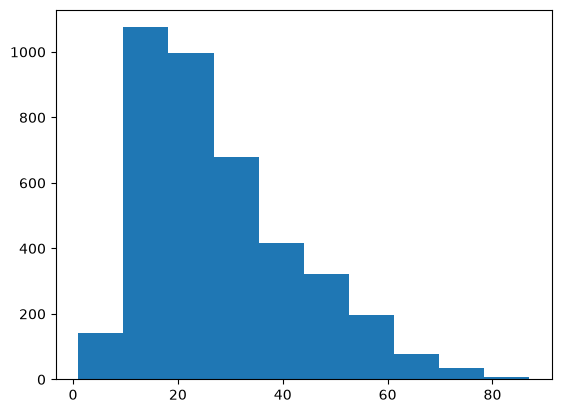

In [52]:
# Question 2:

# Opening the shark attack file using Pandas
df = pd.read_excel('data/GSAF5.xls')
df.head()

# Making a copy of the excel sheet
df.to_excel('data/cleaned_GSAF5.xlsx', index=False, engine='openpyxl')
df.head()

# Drop any columns that do not contain data.
df.drop(columns=['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'], inplace=True)
df.head()

# Cleaning the year variable

# Converting the year column to numbers
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Replacing 0 to the actual year
year_split = df['Date'].str.split(' ')
df['Year'] = df['Year'].fillna(pd.to_numeric(year_split, errors='coerce'))

# Checking the first and last 5 rows of the Year column to see if the data is clean
print(df['Year'].head())
print(df['Year'].tail())

# Filtering since 1940
greater = df[df['Year'] >= 1940]
print(greater)

# Cleaning the Age variable
df['Age'] = df['Age'].replace('?', np.nan)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
print(df['Age'].head())

# Create Histogram of Age variable
plt.hist(df['Age'])

# Proportion of male victims
df['Sex'].equals('M')
male_victums = df[df['Sex'] == 'M']
print(male_victums)
print("Proportion of male victims:", male_victums.shape[0] / df.shape[0])

# Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. 
types = ['Provoked', 'Unprovoked', 'Unknown']
df.loc[~df['Type'].isin(types), 'Type'] = 'Unknown'

# Checking if the previous code was replaced correctly by checking an old value
print(df['Type'] == 'Questionable')

# Checking if it was replaced correctly
print(df['Type'])

# Proportion of unprovoked attacks
unprovoked = df[df['Type'] == 'Unprovoked']
print("Proportion of unprovoked attacks:", unprovoked.shape[0] / df.shape[0])

In [53]:
# Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. 
types = ['Provoked', 'Unprovoked', 'Unknown']
df.loc[~df['Type'].isin(types), 'Type'] = 'Unknown'

# Checking if the previous code was replaced correctly by checking an old value
print(df['Type'] == 'Questionable')

# Checking if it was replaced correctly
print(df['Type'])

# Proportion of unprovoked attacks
unprovoked = df[df['Type'] == 'Unprovoked']
print("Proportion of unprovoked attacks:", unprovoked.shape[0] / df.shape[0])

0       False
1       False
2       False
3       False
4       False
        ...  
7112    False
7113    False
7114    False
7115    False
7116    False
Name: Type, Length: 7117, dtype: bool
0       Unprovoked
1       Unprovoked
2         Provoked
3         Provoked
4       Unprovoked
           ...    
7112    Unprovoked
7113    Unprovoked
7114    Unprovoked
7115    Unprovoked
7116    Unprovoked
Name: Type, Length: 7117, dtype: str
Proportion of unprovoked attacks: 0.7392159617816496


Questions: Are attacks increasing, decreasing, or remaining constant over time? Describe the range of values you see. What proportion of victims are male? What proportion of attacks are unprovoked?

Answers: The attacks are increasing over time. The range of values I see are from 1800s to 2000s such as recent years, 2026, 2025, 2024, etc as well as 1845, 1883, and 1903. The proportion of victims that are male are 80.13%. The proportion of attacks that are unprovoked are 73.92%.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** e371775568ab3384377ec1fd06e5527a23abc792
- **AI tool and model used:** Google Gemini

### *Prompts used

1. I am cleaning a dataframe using python. Would you be able to give me critics on my program for the following questions?

    For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)

    My code:

    **Placed my Question 1 Part 1 Code here**


2. Can you give me an critics on this part of the program as well with these following problems?

    For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

    My code:

    **Placed my Question 1 Part 2 Code here**


3. And the same for this one?

    1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.

    2. Drop any columns that do not contain data.

    3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?

    4. Clean the Age variable and make a histogram of the ages of the victims.

    5. What proportion of victims are male?

    6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
    
    My code:

    **Placed my Question 2 All Parts Code here**


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)

    print(df['Price'].isna().sum())

2. missing_count = df['subject_injury'].isna().sum()

    missing_proportion = df['subject_injury'].isna().mean()

    print(f"Missing count: {missing_count}, Proportion: {missing_proportion:.2%}")

    To see how missing values distribute across force_type:

    print(pd.crosstab(df['subject_injury'].fillna('Missing'), df['force_type'], dropna=False))

3. df = df.dropna(how='all', axis=1)

    plt.hist(df['Age'].dropna(), bins=20)
    
    plt.show() # Don't forget plt.show() to render the plot

    df['Sex'] = df['Sex'].astype(str).str.strip().str.upper()

    male_victims = df[df['Sex'] == 'M']

    print(df['Type'].value_counts(dropna=False))

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | I accept this change because it accounts for parts of the data frame that my original code did not. |
| 2 | Accept | I accept this change because my approach counts the number of null instead of just counting the number of missing subject injuries. |
| 3 | Accept | I accept this change because it accounts for user error such as lowercase and spaces when entering the value. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [54]:
# Your Phase 2 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the raw dataset
df = pd.read_csv('data/airbnb_hw.csv')

# Inspect the initial Price column format
print("Initial Price column head:")
print(df['Price'].head())

# Clean the Price column: use regex to strip out currency symbols (like '$'), 
# commas in prices over 999, and any other non-digit/non-decimal characters
df['Price'] = df['Price'].str.replace(r'[^\d.]', '', regex=True)

# Convert the cleaned strings to numeric data, turning unparseable values into NaN
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("\nData type after conversion:", df['Price'].dtype)

# Calculate and print the final number of missing values (pre-existing + coerced)
missing_count = df['Price'].isna().sum()
print(f"Total missing values in Price: {missing_count}")

# Verify prices larger than 9,99 / 999
print("\nSample prices over 999:")
print(df['Price'][df['Price'] > 999].head())

# Save the fully cleaned dataframe to a new CSV file
df.to_csv('data/cleaned_data_airbnb_hw.csv', index=False)

# Load the raw dataset
df = pd.read_csv('data/mn_police_use_of_force.csv')

# Inspect columns
df.head()

# Calculate missing count and proportion
missing_count = df['subject_injury'].isna().sum()
missing_proportion = df['subject_injury'].isna().mean()
print(f"Missing subject_injury count: {missing_count}")
print(f"Proportion missing: {missing_proportion:.4f}")

# Cross-tabulate including missing values to check for patterns across force_type
print("\nCross-tabulation of subject_injury (with Missing) vs force_type:")
print(pd.crosstab(df['subject_injury'].fillna('Missing'), df['force_type'], dropna=False))

# (Optional/If required by your assignment) Handle NAs
# Note: Ensure your imputation logic aligns with your assignment guidelines
df['subject_injury_cleaned'] = df['subject_injury'].fillna(df['force_type'].map({
    'Bodily Force': 'Yes',
    'Chemical Irritant': 'No',
    'Taser': 'No',
    'Improvised Weapon': 'No',
    'Gun Point Display': 'Yes',
    'Police K9 Bite': 'Yes'
}))

# Save the fully cleaned dataframe at the end
df.to_csv('data/cleaned_mn_police_use_of_force.csv', index=False)

Initial Price column head:
0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: str

Data type after conversion: int64
Total missing values in Price: 0

Sample prices over 999:
101     1990
263     1000
764     1200
1272    1000
1275    5000
Name: Price, dtype: int64
Missing subject_injury count: 9848
Proportion missing: 0.7619

Cross-tabulation of subject_injury (with Missing) vs force_type:
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing             2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing                        27                 74           87   
No                             33                

Attacks per year trend preview:
Year
2017.0    141
2018.0    124
2019.0    114
2020.0    101
2021.0    111
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, dtype: int64


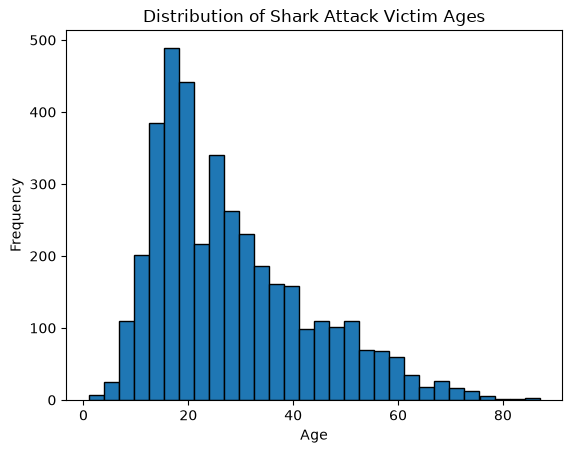

Proportion of male victims: 0.8027

Type value counts:
Type
Unprovoked    5261
Unknown       1207
Provoked       649
Name: count, dtype: int64
Proportion of unprovoked attacks: 0.7392


In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Open file and drop truly empty columns
df = pd.read_excel('data/GSAF5.xls')
df = df.dropna(how='all', axis=1)

# 2. Clean the Year variable
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
# Alternative regex extraction from Date if Year has missing/messy entries:
# extracted_years = df['Date'].str.extract(r'(\d{4})')[0]
# df['Year'] = df['Year'].fillna(pd.to_numeric(extracted_years, errors='coerce'))

# Filter since 1940 and analyze trend
attacks_since_1940 = df[df['Year'] >= 1940]
print("Attacks per year trend preview:")
print(attacks_since_1940['Year'].value_counts().sort_index().tail(10))

# 3. Clean Age and plot histogram
df['Age'] = pd.to_numeric(df['Age'].replace('?', np.nan), errors='coerce')
plt.figure()
plt.hist(df['Age'].dropna(), bins=30, edgecolor='black')
plt.title("Distribution of Shark Attack Victim Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 4. Clean Sex and calculate male proportion
df['Sex'] = df['Sex'].astype(str).str.strip().str.upper()
male_count = (df['Sex'] == 'M').sum()
total_count = len(df)
print(f"Proportion of male victims: {male_count / total_count:.4f}")

# 5. Clean Type variable
df['Type'] = df['Type'].astype(str).str.strip()
allowed_types = ['Provoked', 'Unprovoked']
df.loc[~df['Type'].isin(allowed_types), 'Type'] = 'Unknown'

# Verify type cleaning
print("\nType value counts:")
print(df['Type'].value_counts(dropna=False))

# Calculate unprovoked proportion
unprovoked_count = (df['Type'] == 'Unprovoked').sum()
print(f"Proportion of unprovoked attacks: {unprovoked_count / total_count:.4f}")

# Save the fully cleaned dataset at the end
df.to_excel('data/cleaned_GSAF5.xlsx', index=False, engine='openpyxl')

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]